#### 0) Import Libraries 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import json
from pathlib import Path

#### 1) Configurations 

In [6]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

tickers = ["AAPL", "META", "MSFT", "TSLA"]

baseline_mode = "ATR"
baseline_strat = "final_position_EMA"

#### 2) Helpher functions for Analytics

In [10]:
def calculate_streaks(returns_series):
    is_win = returns_series > 0
    is_loss = returns_series < 0

    win_blocks = is_win.groupby((is_win != is_win.shift()).cumsum()).sum() # counts number of consective wins and records the number
    max_win_streak = win_blocks[is_win].max() if not win_blocks[is_win].empty else 0

    loss_blocks = is_loss.groupby((is_loss != is_loss.shift()).cumsum()).sum() # counts number of consective losses and records the number
    max_loss_streak = loss_blocks[is_loss].max() if not loss_blocks[is_loss].empty else 0

    return max_win_streak, max_loss_streak

#### 3) Core Trade Analytics Engine

In [11]:
analytics_results = []
kelly_fractions = {}

for ticker in tickers:
    filepath = output_dir / f"trades_{ticker}_{baseline_mode}_{baseline_strat}.parquet"
    if not filepath.exists():
        print(f"Missing data for {ticker}")
        continue
        
    df = pd.read_parquet(filepath)
    if df.empty:
        continue
        
    returns = df["Return %"]
    win_trades = df[returns > 0] # +Pnl Trades
    loss_trades = df[returns <= 0] # -Pnl Trades
    
    win_rate = len(win_trades) / len(df) # +PnL trades %
    avg_win = win_trades["Return %"].mean() if not win_trades.empty else 0.0 # When we win how much do we make on average?
    avg_loss = abs(loss_trades["Return %"].mean()) if not loss_trades.empty else 0.0 # When we lose, How much do we lose on average?
    profit_factor = (avg_win * len(win_trades)) / (avg_loss * len(loss_trades)) if profit_factor > 0 else 0.0 # How much do we make on avg per 1 unit of loss
    
    payoff_ratio = avg_win / avg_loss if avg_loss > 0 else 0.0 # How much do we make on avg per 1 unit of loss
    
    expectancy = (win_rate * avg_win) - ((1 - win_rate) * avg_loss) # What is the expected PnL per trade?
    avg_holding = df["Holding Days"].mean() # How long do we hold on average?
    expectancy_per_day = expectancy / avg_holding if avg_holding > 0 else 0.0 # What is the expected PnL per day
    
    skewness = returns.skew() # Positive skew → occasional large wins (trend‑following), Negative skew → occasional large losses (mean‑reversion)
    kurt = returns.kurtosis() # How large are the tails?
    
    pct_5 = returns.quantile(0.05) # What were the returns in the bottom 5%?
    pct_95 = returns.quantile(0.95) # What were the returns in the top 5%?
    
    max_win_streak, max_loss_streak = calculate_streaks(returns) # Consecutive wins and losses
    
    kelly = win_rate - ((1 - win_rate) / payoff_ratio) if payoff_ratio > 0 else 0.0 # given on avg how often we win and how much, what should our lot size be?
    half_kelly = kelly / 2.0 # kelly tends to be too aggressive
    
    kelly_fractions[ticker] = kelly
    
    exit_counts = df["Exit Type"].value_counts().to_dict()
    
    analytics_results.append({
        "Ticker": ticker,
        "Trades": len(df),
        "Win Rate": win_rate,
        "Profit Factor" : profit_factor,
        "Payoff Ratio": payoff_ratio,
        "Expectancy": expectancy,
        "Exp/Day": expectancy_per_day,
        "Skew": skewness,
        "Kurtosis": kurt,
        "5th Pct": pct_5,
        "95th Pct": pct_95,
        "Max Win Streak": max_win_streak,
        "Max Loss Streak": max_loss_streak,
        "Kelly": kelly,
        "Half Kelly": half_kelly,
        "Exit SL": exit_counts.get("SL", 0),
        "Exit Signal": exit_counts.get("Signal", 0)
    })

df_analytics = pd.DataFrame(analytics_results)
df_analytics.to_parquet(output_dir / "trade_analytics_summary.parquet")

with open(output_dir / "kelly_fractions.json", "w") as f:
    json.dump(kelly_fractions, f)

print("Consolidated Trade Analytics Summary")
print(df_analytics.set_index("Ticker").T)

Consolidated Trade Analytics Summary
Ticker                AAPL       META        MSFT       TSLA
Trades           98.000000  91.000000  105.000000  97.000000
Win Rate          0.377551   0.362637    0.380952   0.360825
Profit Factor     2.583207   2.375582    1.962138   4.356397
Payoff Ratio      4.258801   4.175266    3.188475   7.717046
Expectancy        0.027133   0.024251    0.014609   0.082667
Exp/Day           0.001118   0.001089    0.000624   0.004216
Skew              3.147461   3.332504    1.841807   5.929902
Kurtosis         12.218649  12.647282    2.951262  40.353476
5th Pct          -0.052100  -0.059355   -0.046249  -0.073753
95th Pct          0.231521   0.267888    0.184413   0.550078
Max Win Streak    1.000000   5.000000    4.000000   3.000000
Max Loss Streak   7.000000   6.000000    7.000000   7.000000
Kelly             0.231395   0.209985    0.186801   0.277998
Half Kelly        0.115698   0.104993    0.093400   0.138999
Exit SL          30.000000  21.000000   26.00000

#### 4) Sizing Risk Warnings 

In [12]:
print("Position Sizing Diagnostics")
for ticker in tickers:
    kelly_val = kelly_fractions.get(ticker, 0)
    if kelly_val > 0.25:
        print(f"WARNING for {ticker}: Full Kelly fraction is {kelly_val:.2%}. This exceeds the 25% safety threshold and implies extreme volatility risk. Use Half-Kelly or smaller.")
    else:
        print(f"{ticker} Kelly fraction: {kelly_val:.2%}. Half-Kelly: {kelly_val/2:.2%}")

Position Sizing Diagnostics
AAPL Kelly fraction: 23.14%. Half-Kelly: 11.57%
META Kelly fraction: 21.00%. Half-Kelly: 10.50%
MSFT Kelly fraction: 18.68%. Half-Kelly: 9.34%
WARNING for TSLA: Full Kelly fraction is 27.80%. This exceeds the 25% safety threshold and implies extreme volatility risk. Use Half-Kelly or smaller.


#### 5) Distribution and Excursion Visualizations

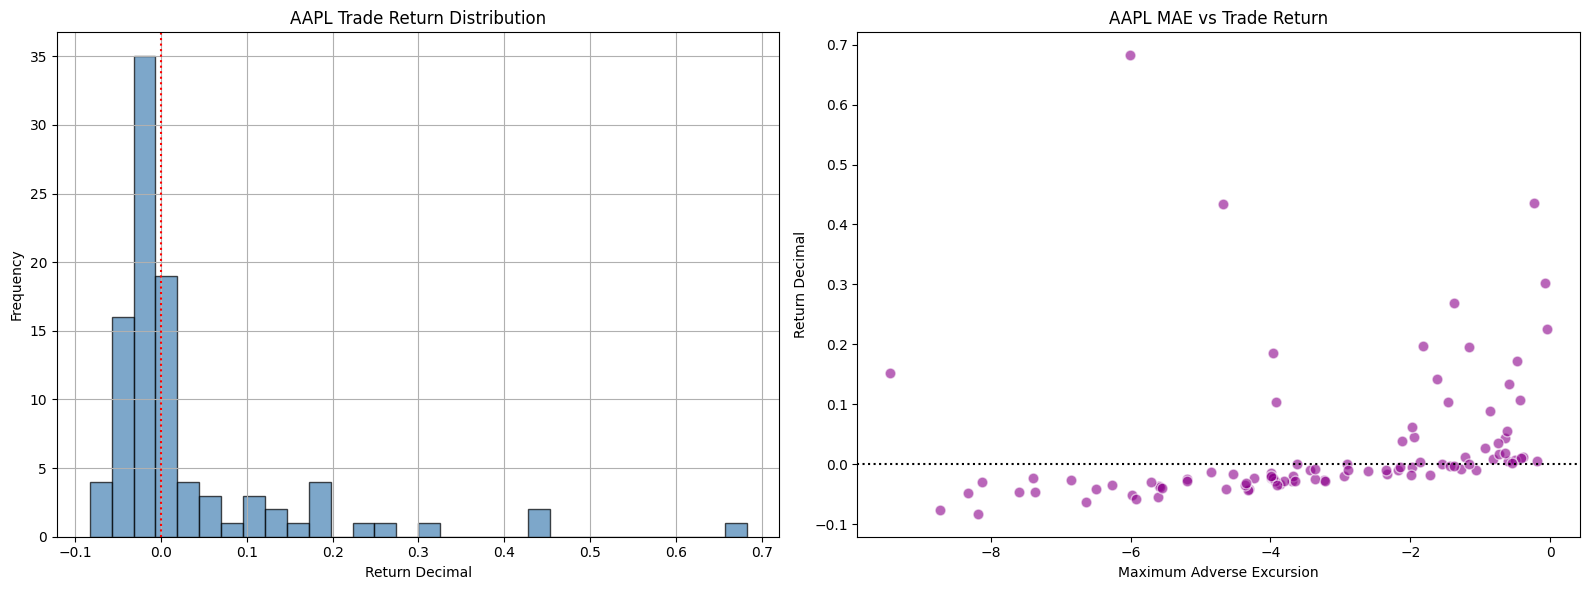

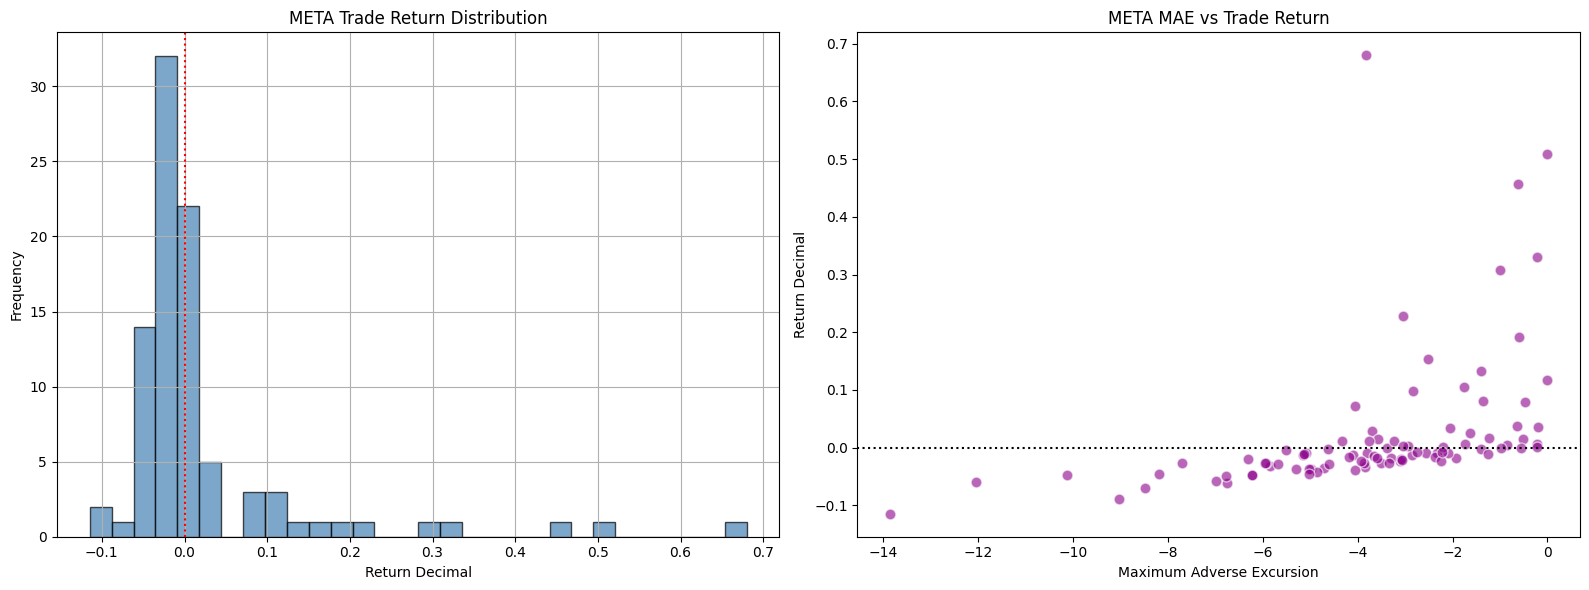

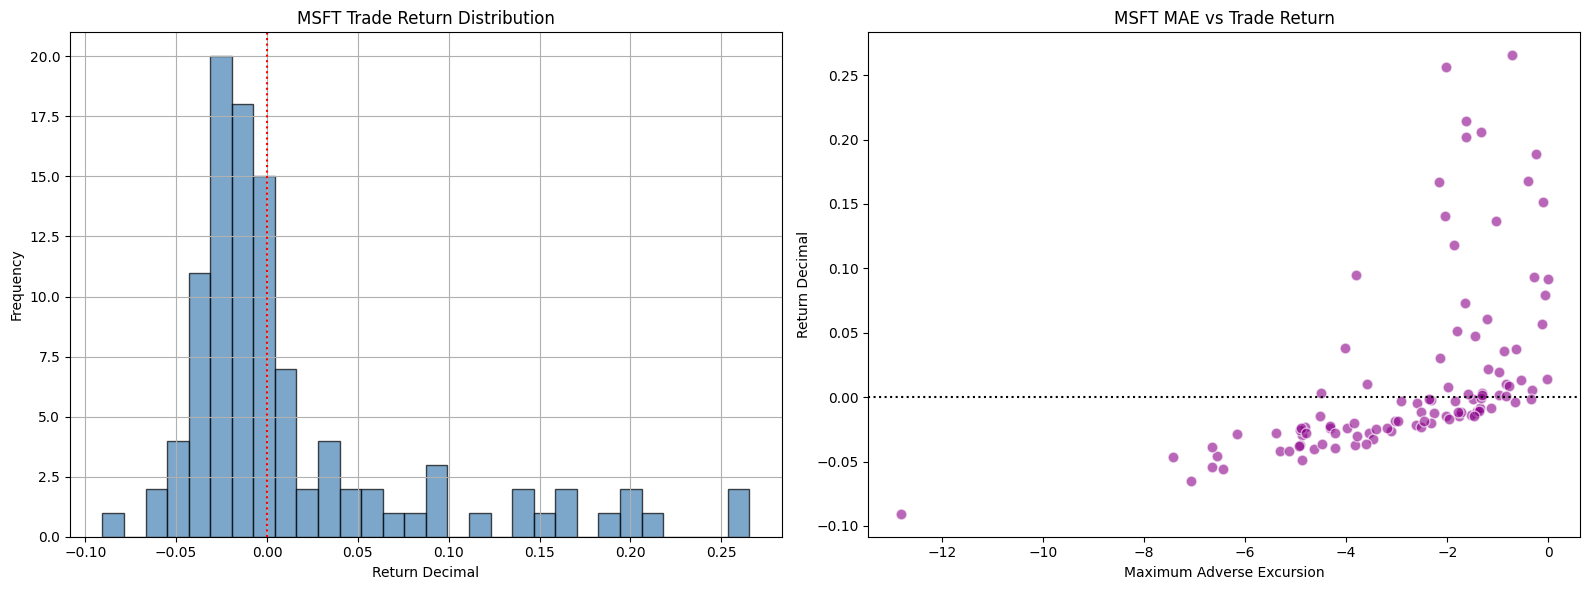

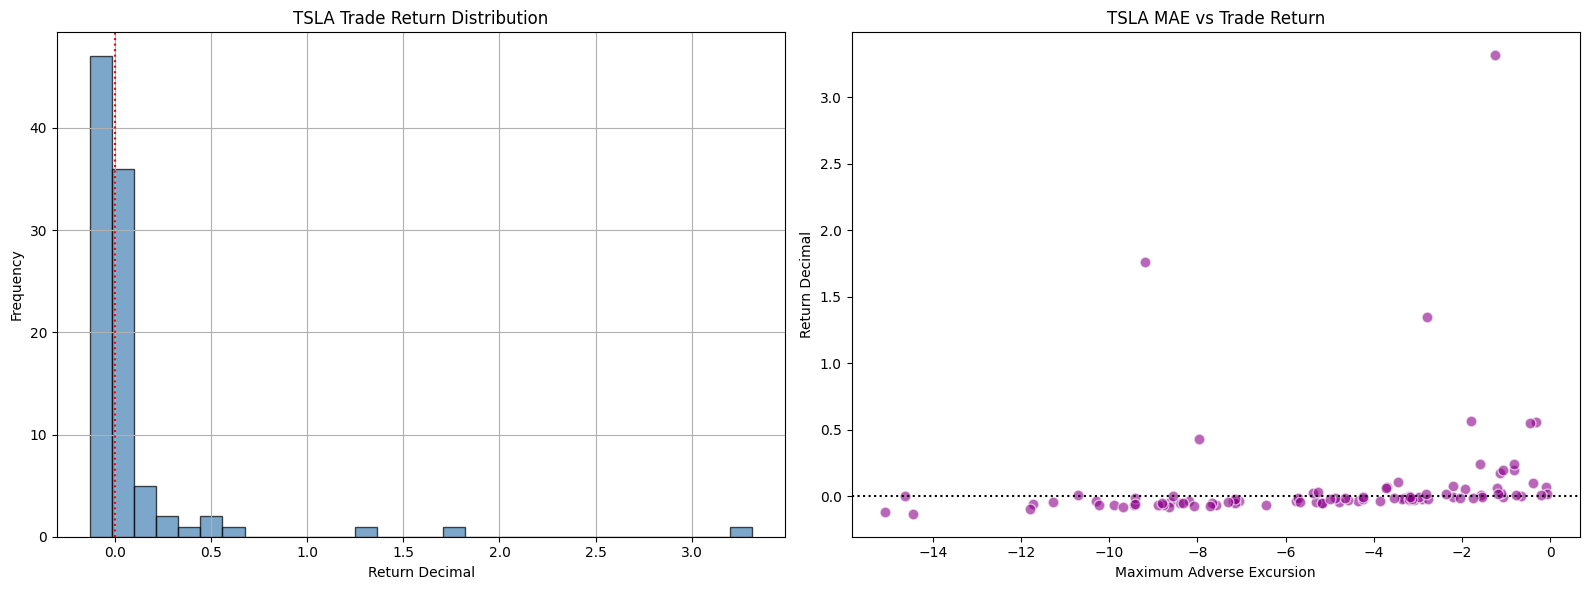

In [13]:
for ticker in tickers:
    filepath = output_dir / f"trades_{ticker}_{baseline_mode}_{baseline_strat}.parquet"
    if not filepath.exists():
        continue
        
    df = pd.read_parquet(filepath)
    if df.empty:
        continue
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    df["Return %"].hist(bins=30, ax=ax1, alpha=0.7, color="steelblue", edgecolor="black")
    ax1.set_title(f"{ticker} Trade Return Distribution")
    ax1.set_xlabel("Return Decimal")
    ax1.set_ylabel("Frequency")
    ax1.axvline(x=0, color="red", linestyle=":")
    
    ax2.scatter(df["MAE"], df["Return %"], alpha=0.6, color="darkmagenta", edgecolor="white", s=60)
    ax2.set_title(f"{ticker} MAE vs Trade Return")
    ax2.set_xlabel("Maximum Adverse Excursion")
    ax2.set_ylabel("Return Decimal")
    ax2.axhline(y=0, color="black", linestyle=":")
    
    plt.tight_layout()
    plt.show()